Тема лаб2: Алгоритми навчання без учителя та обробка текстових даних (Scikit-learn lib)

## **Завдання 1:**
Зниження розмірності та візуалізація даних

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Завантаження датасету

In [2]:
data_frame = pd.read_csv("var_data/phones.csv")
data_frame

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


Виконуємо стандартну обробку датасету: виділили цільову змінну `price_range` (діапазон ціни телефона: 0 - низький, 1 - середній, 2 - вище середнього, 3 - високий). Інші ознаки представлені числовому форматі

In [3]:
TARGET_VAR = "price_range"
OTHER_FEATURES = [col for col in data_frame.columns if col != TARGET_VAR]

data_frame

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


Відокремимо ознаки (характеристики телефонів) та цільову змінну (діапазон ціни). Перетворимо дані за допомогою StandardScaler для нормалізації масштабів різних характеристик.

In [4]:
X = data_frame.drop(columns=[TARGET_VAR])
y = data_frame[TARGET_VAR]

X.dtypes

battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
dtype: object

In [5]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [6]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [7]:
X_std

array([[-0.90259726, -0.9900495 ,  0.83077942, ..., -1.78686097,
        -1.00601811,  0.98609664],
       [-0.49513857,  1.0100505 , -1.2530642 , ...,  0.55964063,
         0.99401789, -1.01409939],
       [-1.5376865 ,  1.0100505 , -1.2530642 , ...,  0.55964063,
         0.99401789, -1.01409939],
       ...,
       [ 1.53077336, -0.9900495 , -0.76274805, ...,  0.55964063,
         0.99401789, -1.01409939],
       [ 0.62252745, -0.9900495 , -0.76274805, ...,  0.55964063,
         0.99401789,  0.98609664],
       [-1.65833069,  1.0100505 ,  0.58562134, ...,  0.55964063,
         0.99401789,  0.98609664]], shape=(2000, 20))

Розглянемо дисперсії по кожній змінній (характеристиці телефону) за допомогою Principal component analysis (PCA). Аналіз основних компонент допоможе визначити, які комбіновані ознаки пояснюють найбільшу варіативність у даних про телефони.

In [8]:
pca = PCA()
X_pca = pca.fit_transform(X_std)

In [9]:
pca

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [10]:
X_pca

array([[ 0.32349681, -2.61689384, -0.58773344, ...,  0.26711761,
        -0.676584  , -0.38977576],
       [-1.99834007,  0.57283586,  0.34467906, ..., -1.39179619,
        -0.03966889,  0.01773135],
       [-1.30146542,  0.19010079,  0.08544072, ...,  0.02953012,
        -0.1207363 , -0.19336213],
       ...,
       [-1.25534097, -0.16603296, -0.74708239, ..., -0.25019249,
        -0.2142378 , -0.42217864],
       [-1.22399354,  0.95009442, -0.80027601, ...,  0.18521468,
        -0.30420687, -0.53440475],
       [ 0.01819746,  1.4620912 , -0.6055566 , ..., -0.47231604,
        -0.22182146,  0.40613646]], shape=(2000, 20))

Частка поясненої дисперсії кожною компонентою -- скільки інформації (варіативності) з оригінальних даних містить кожна головна компонента.

In [11]:
exp_var_pca = pca.explained_variance_ratio_
exp_var_pca

array([0.08386288, 0.08112475, 0.07912854, 0.07145225, 0.05607555,
       0.05435682, 0.05328221, 0.05102092, 0.05085209, 0.05028427,
       0.04903619, 0.0487416 , 0.04761192, 0.04758246, 0.04494168,
       0.04380595, 0.02504022, 0.02361498, 0.02064192, 0.0175428 ])

Кумулятивна сума поясненої дисперсії (кількість інформації що збережеться, якщо буде взято 1... N х-тик)

In [12]:
cum_sum_eigenvalues = np.cumsum(exp_var_pca)
cum_sum_eigenvalues

array([0.08386288, 0.16498763, 0.24411617, 0.31556842, 0.37164398,
       0.42600079, 0.47928301, 0.53030392, 0.58115601, 0.63144028,
       0.68047647, 0.72921807, 0.77682999, 0.82441245, 0.86935413,
       0.91316009, 0.9382003 , 0.96181529, 0.9824572 , 1.        ])

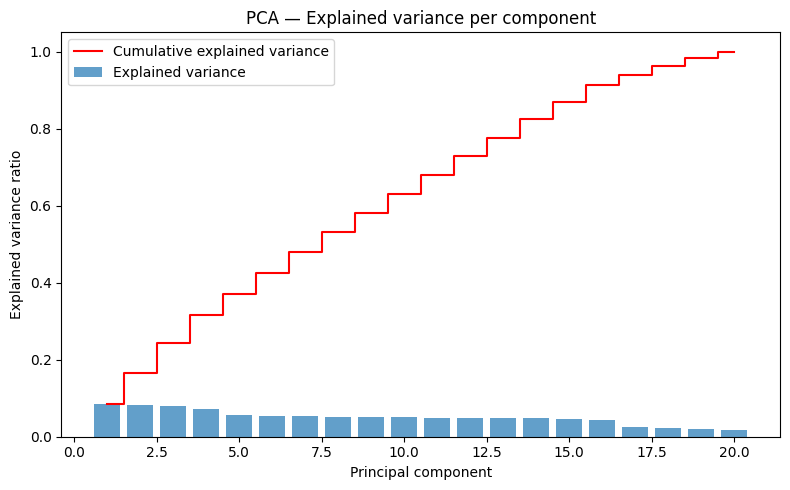

In [13]:
plt.figure(figsize=(8,5))

plt.bar(range(1, len(exp_var_pca)+1), exp_var_pca,
        align='center', alpha=0.7, label='Explained variance')

plt.step(range(1, len(cum_sum_eigenvalues)+1), cum_sum_eigenvalues,
         where='mid', color='red', label='Cumulative explained variance')

plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component')
plt.title('PCA — Explained variance per component')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Застосуємо PCA, щоб знизити розмірність

In [14]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_std)

In [15]:
pca

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [16]:
pca_result

array([[ 0.32349681, -2.61689384],
       [-1.99834007,  0.57283586],
       [-1.30146542,  0.19010079],
       ...,
       [-1.25534097, -0.16603296],
       [-1.22399354,  0.95009442],
       [ 0.01819746,  1.4620912 ]], shape=(2000, 2))

Формуємо датафрейм для побудови графіка

In [17]:
pca_result_df = pd.DataFrame({
    'pca_1': pca_result[:, 0],
    'pca_2': pca_result[:, 1],
    'label': y
})
pca_result_df

,pca_1,pca_2,label
0,0.323497,-2.616894,1
1,-1.998340,0.572836,2
2,-1.301465,0.190101,2
3,-1.149410,-0.274381,2
4,1.636494,1.291291,1
...,...,...,...
1995,-0.903997,0.581778,0
1996,-1.445462,-0.839583,2
1997,-1.255341,-0.166033,3
1998,-1.223994,0.950094,0


<Axes: xlabel='pca_1', ylabel='pca_2'>

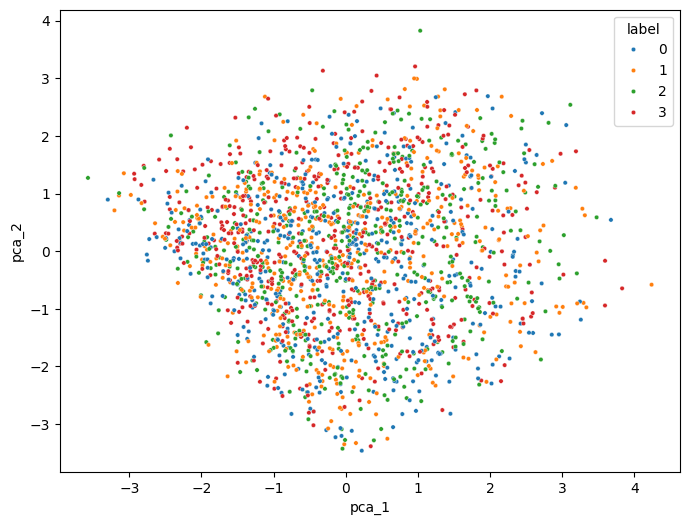

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='pca_1',
    y='pca_2',
    hue='label',
    palette='tab10',
    data=pca_result_df,
    s=10
)

Тренуємо дерево рішень на повних ознаках, вимірюємо точність та час навчання.

In [19]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

In [21]:
base_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)
base_tree

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
t0 = time.time()
base_tree.fit(X_train, y_train)
train_time_base = time.time() - t0

y_pred_base = base_tree.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base, average="weighted")

In [23]:
print(f"Accuracy (без PCA): {acc_base:.4f}")
print(f"F1-score (без PCA): {f1_base:.4f}")
print(f"Час навчання (без PCA): {train_time_base:.4f} c")

Accuracy (без PCA): 0.8300
F1-score (без PCA): 0.8302
Час навчання (без PCA): 0.0148 c


Виконуємо PCA 

In [24]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

In [25]:
tree_pca = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)
tree_pca

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
t0 = time.time()
tree_pca.fit(X_train_pca, y_train)
train_time_pca = time.time() - t0

y_pred_pca = tree_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca, average="weighted")

In [27]:
print(f"Accuracy (PCA): {acc_pca:.4f}")
print(f"F1-score (PCA): {f1_pca:.4f}")
print(f"Час навчання (PCA): {train_time_pca:.4f} c")

Accuracy (PCA): 0.2750
F1-score (PCA): 0.2744
Час навчання (PCA): 0.0102 c


Порівняння показників

In [28]:
results = pd.DataFrame([
    {"Модель": "Decision Tree (без PCA)", "Accuracy": acc_base, "F1 (weighted)": f1_base, "Час навчання, с": train_time_base},
    {"Модель": "Decision Tree (з PCA)",   "Accuracy": acc_pca,  "F1 (weighted)": f1_pca,  "Час навчання, с": train_time_pca},
])

results

,Модель,Accuracy,F1 (weighted),"Час навчання, с"
0,Decision Tree (без PCA),0.830,0.830168,0.014821
1,Decision Tree (з PCA),0.275,0.274374,0.010236


Висновки:

**1. Вплив PCA на точність класифікації**

Результати показують **драматичне зниження точності** після застосування PCA з 2 компонентами:
- **Без PCA:** Accuracy = 83.00%, F1-score = 83.02%
- **З PCA (2 компоненти):** Accuracy = 27.50%, F1-score = 27.44%
- **Втрата точності:** 55.5 процентних пунктів (-67% відносно початкової точності)

Таке катастрофічне падіння точності пояснюється тим, що **перші 2 компоненти PCA зберігають лише 16.5% дисперсії** з оригінальних даних:
- 1-ша компонента: 8.39% поясненої дисперсії
- 2-га компонента: 8.11% поясненої дисперсії
- **Разом: 16.50%** - це означає, що **83.5% інформації втрачається!**

**2. Вплив на швидкість навчання**

Час навчання моделі зменшився, але несуттєво:
- **Без PCA:** 0.0148 секунди
- **З PCA:** 0.0102 секунди
- **Зменшення часу:** 0.0046 с (31% швидше)

Прискорення навчання є незначним, особливо враховуючи катастрофічну втрату точності.

**3. Чому точність впала так сильно?**

Датасет телефонів містить 20 характеристик (RAM, батарея, роздільність камер, розмір екрану тощо). Аналіз explained variance показує, що:
- Дисперсія **рівномірно розподілена** між усіма характеристиками
- Немає 1-2 домінуючих ознак
- Для збереження 80% інформації потрібно **щонайменше 14 компонент** (82.44% cumulative variance)

Це означає, що для визначення цінового діапазону телефону важливі **майже всі 20 характеристик**, а не лише декілька головних.

**4. Загальний висновок**

Для даного датасету телефонів **зниження до 2 компонент є непридатним** для класифікації:
- Точність падає з 83% до 27.5% (нижче за випадкове вгадування для 4 класів - 25%)
- Втрачається 83.5% інформації про характеристики телефонів
- Час навчання зменшується на 31%, але це не компенсує втрату точності
- Для збереження прийнятної точності (~80%) потрібно використовувати **щонайменше(!) 13-14 компонент**
- Якщо потрібна візуалізація (2D), PCA підходить, але не для класифікації
- Для цього датасету краще використовувати всі оригінальні ознаки або feature selection замість PCA

Для візуалізації також можемо скористатися методом tSNE

In [29]:
y_codes, y_uniques = pd.factorize(y)

In [30]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_std)


In [31]:
tsne

,n_components,2
,perplexity,30
,early_exaggeration,12.0
,learning_rate,'auto'
,max_iter,1000
,n_iter_without_progress,300
,min_grad_norm,1e-07
,metric,'euclidean'
,metric_params,None
,init,'pca'
,verbose,0


In [32]:
X_tsne

array([[ 25.565205  , -26.560978  ],
       [  5.033876  ,  36.942333  ],
       [  5.2633696 ,  37.470123  ],
       ...,
       [ -0.36532292,  22.69291   ],
       [-14.530675  ,   0.8637007 ],
       [-49.36897   ,  15.409689  ]], shape=(2000, 2), dtype=float32)

Формуємо датафрейм для побудови графіка

In [33]:
tsne_result_df = pd.DataFrame({
    'tsne_1': X_tsne[:, 0],
    'tsne_2': X_tsne[:, 1],
    'label': y
})
tsne_result_df

,tsne_1,tsne_2,label
0,25.565205,-26.560978,1
1,5.033876,36.942333,2
2,5.263370,37.470123,2
3,7.882059,1.067323,2
4,-40.458035,-10.720304,1
...,...,...,...
1995,-12.675252,48.711494,0
1996,20.315145,12.002656,2
1997,-0.365323,22.692909,3
1998,-14.530675,0.863701,0


<Axes: xlabel='tsne_1', ylabel='tsne_2'>

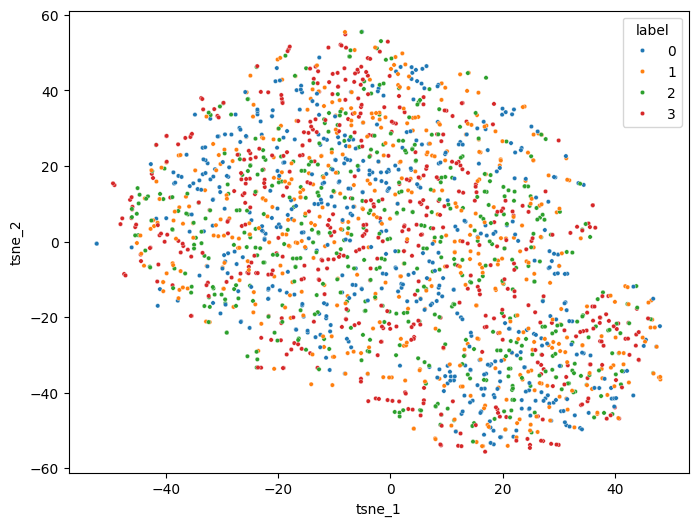

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='tsne_1',
    y='tsne_2',
    hue='label',
    palette='tab10',
    data=tsne_result_df,
    s=10
)

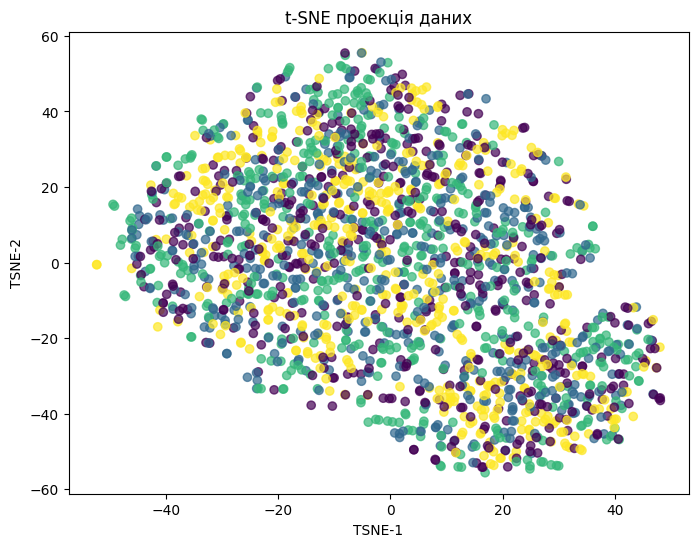

In [35]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_codes, alpha=0.7)
plt.title('t-SNE проекція даних')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.show()

На отриманому графіку t-SNE проекції видно двовимірне представлення 2000 телефонів, де кожен колір відповідає одному з чотирьох цінових діапазонів (0-низький, 1-середній, 2-вище середнього, 3-високий).

**1. Структура кластерів**
- Точки **різних кольорів значно перекриваються**, формуючи складну мозаїку замість чітко відокремлених груп
- Немає яскраво виражених ізольованих кластерів для різних цінових категорій
- Деякі телефони з різних цінових діапазонів розташовані близько один до одного, що вказує на схожість їхніх характеристик

**2. Інтерпретація перекриття**
Значне перекриття класів пояснюється тим, що:
- **Телефони середніх цінових категорій** (1 і 2) мають перехідні характеристики
- Існують **бюджетні телефони з окремими флагманськими характеристиками** (наприклад, хороша камера але малий RAM)
- Деякі **дорогі телефони можуть мати середні показники** окремих характеристик
- Ціна залежить від **комбінації всіх 20 характеристик**, а не від однієї чи двох

**3. Зниження розмірності до 2D**
t-SNE зменшення до 2D показало, що:
- **Візуалізація структури даних** - успішна, можна побачити загальний розподіл
- **Чітке розділення класів** - неможливе, занадто велике перекриття
- **Покращення якості класифікації** - відсутнє

---
**Висновок:** t-SNE корисний як **інструмент візуалізації та дослідження даних**, щоб зрозуміти структуру датасету, але не підходить для зменшення розмірності перед класифікацією, коли потрібна висока точність. Для датасету телефонів візуалізація підтверджує, що цінові діапазони визначаються складною комбінацією багатьох характеристик, а не одним чи двома головними факторами.

**Порівняння t-SNE та PCA**
Обидва методи зниження розмірності до 2D показують, що:
- Датасет телефонів має **складну 20-вимірну структуру**
- Проекція на 2D **не зберігає достатньо інформації** для точної класифікації
- Візуалізація корисна для **дослідження даних**, але не для побудови класифікаторів

**Чи відбулося покращення при зниженні розмірності до 2D?**
- Не покращило якість класифікації - навпаки, значно погіршило: з 83% до 27.5%
- Не проявилися чіткі кластери цінових категорій
- Додатково підтвердило складність задачі, що для точної класифікації цін телефонів потрібні всі або майже всі 20 характеристик

## **Завдання 2:**
Кластерний аналіз

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.utils import shuffle

In [37]:
def recreate_image(codebook: np.ndarray, labels: np.ndarray, width: int, height: int) -> np.ndarray:
    image = codebook[labels]
    return image.reshape(height, width, -1)

In [38]:
image = Image.open('var_data/image.jpg')
image_data_scaled = np.array(image, dtype=np.float64) / 255

Відображення зображення

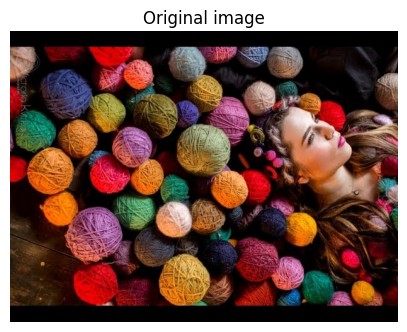

In [39]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title('Original image')
plt.imshow(image_data_scaled)
plt.show()

Зведемо зобранження у двовимірний масив для застосування K-Means


Отримуємо розміри зображення

In [40]:
img_height, img_width, img_channels = image_data_scaled.shape
assert img_channels == 3, f"Очікується 3 канали (RGB), але знайдено {img_channels}"
img_height, img_width, img_channels

(480, 640, 3)

Перетворюємо 3D масив (H, W, C) у 2D (H*W, C)

In [41]:
pixels_2d = np.reshape(image_data_scaled, (img_height * img_width, img_channels))
pixels_2d

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       ...,
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], shape=(307200, 3))

Стискання за допомогою K-Means до 64 кольорів

In [42]:
palette_size = 64

Вибірка пікселів для навчання

In [43]:
sample_pixels = shuffle(pixels_2d, random_state=0, n_samples=1000)
sample_pixels

array([[0.08627451, 0.03137255, 0.        ],
       [0.01568627, 0.01568627, 0.02352941],
       [0.61960784, 0.21568627, 0.32941176],
       ...,
       [0.16470588, 0.09411765, 0.01568627],
       [0.82745098, 0.62352941, 0.54117647],
       [0.00392157, 0.        , 0.        ]], shape=(1000, 3))

Навчання K-Means та прогноз міток для всіх пікселів

In [44]:
kmeans_model = KMeans(n_clusters=palette_size, random_state=0)
kmeans_model.fit(sample_pixels)
pixel_labels = kmeans_model.predict(pixels_2d)
pixel_labels

array([6, 6, 6, ..., 6, 6, 6], shape=(307200,), dtype=int32)

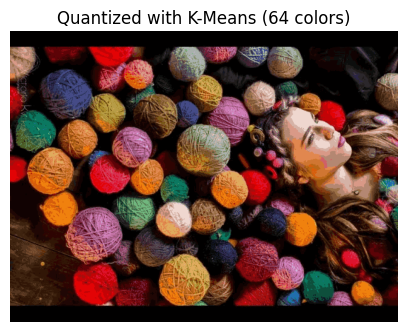

In [45]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title(f'Quantized with K-Means ({palette_size} colors)')
plt.imshow(recreate_image(kmeans_model.cluster_centers_, pixel_labels, img_width, img_height))
plt.show()

In [46]:
kmeans_model.cluster_centers_

array([[0.12874223, 0.0312769 , 0.01960784],
       [0.73098039, 0.4054902 , 0.09490196],
       [0.85294118, 0.60294118, 0.53039216],
       [0.35      , 0.34607843, 0.40098039],
       [0.65266106, 0.0557423 , 0.0535014 ],
       [0.45849673, 0.12385621, 0.22124183],
       [0.00618816, 0.00255442, 0.0033819 ],
       [0.17156863, 0.14607843, 0.27745098],
       [0.33065015, 0.20784314, 0.1244582 ],
       [0.86823529, 0.0745098 , 0.17803922],
       [0.81519608, 0.37745098, 0.40735294],
       [0.80784314, 0.72156863, 0.8627451 ],
       [0.36802413, 0.0147813 , 0.02956259],
       [0.04411765, 0.47254902, 0.37990196],
       [0.47490196, 0.34941176, 0.09176471],
       [0.94248366, 0.50640523, 0.05594771],
       [0.50135747, 0.33453997, 0.20603318],
       [0.6087146 , 0.36165577, 0.48845316],
       [0.70896359, 0.53221289, 0.44733894],
       [0.88522876, 0.53045752, 0.31137255],
       [0.24357298, 0.13783588, 0.06187364],
       [0.32026144, 0.25620915, 0.28522876],
       [0.

Стискання за допомогою K-Means до 32 кольорів

In [47]:
palette_size = 32

In [48]:
sample_pixels = shuffle(pixels_2d, random_state=0, n_samples=1000)
sample_pixels

array([[0.08627451, 0.03137255, 0.        ],
       [0.01568627, 0.01568627, 0.02352941],
       [0.61960784, 0.21568627, 0.32941176],
       ...,
       [0.16470588, 0.09411765, 0.01568627],
       [0.82745098, 0.62352941, 0.54117647],
       [0.00392157, 0.        , 0.        ]], shape=(1000, 3))

In [49]:
kmeans_model = KMeans(n_clusters=palette_size, random_state=0)
kmeans_model.fit(sample_pixels)
pixel_labels = kmeans_model.predict(pixels_2d)
pixel_labels

array([5, 5, 5, ..., 5, 5, 5], shape=(307200,), dtype=int32)

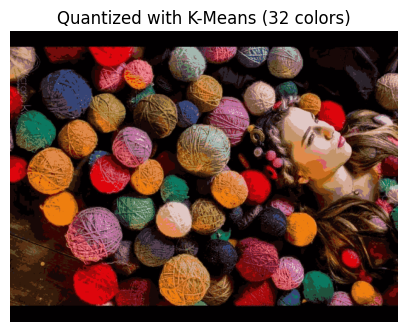

In [50]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title(f'Quantized with K-Means ({palette_size} colors)')
plt.imshow(recreate_image(kmeans_model.cluster_centers_, pixel_labels, img_width, img_height))
plt.show()

In [51]:
kmeans_model.cluster_centers_

array([[0.09448076, 0.0325345 , 0.0291939 ],
       [0.79483066, 0.42352941, 0.12655971],
       [0.92745098, 0.51764706, 0.55686275],
       [0.46614379, 0.12261438, 0.21934641],
       [0.35577342, 0.29281046, 0.15599129],
       [0.01024772, 0.00355039, 0.00429275],
       [0.59649123, 0.43426213, 0.46398349],
       [0.86713725, 0.02321569, 0.04815686],
       [0.82641899, 0.66006192, 0.58575851],
       [0.16803069, 0.13520887, 0.16658142],
       [0.04411765, 0.47254902, 0.37990196],
       [0.45283224, 0.04945534, 0.04444444],
       [0.21269841, 0.26853408, 0.46255836],
       [0.65421995, 0.03870418, 0.04501279],
       [0.49785247, 0.24985994, 0.07002801],
       [0.70906863, 0.21642157, 0.28602941],
       [0.87696078, 0.53888889, 0.29166667],
       [0.48613928, 0.34874915, 0.25679513],
       [0.9372549 , 0.49434833, 0.06020761],
       [0.64235294, 0.71843137, 0.68941176],
       [0.76764706, 0.58352941, 0.41803922],
       [0.20936819, 0.10929557, 0.04335512],
       [0.

Стискання за допомогою K-Means до 16 кольорів

In [52]:
palette_size = 16

In [53]:
sample_pixels = shuffle(pixels_2d, random_state=0, n_samples=1000)
sample_pixels

array([[0.08627451, 0.03137255, 0.        ],
       [0.01568627, 0.01568627, 0.02352941],
       [0.61960784, 0.21568627, 0.32941176],
       ...,
       [0.16470588, 0.09411765, 0.01568627],
       [0.82745098, 0.62352941, 0.54117647],
       [0.00392157, 0.        , 0.        ]], shape=(1000, 3))

In [54]:
kmeans_model = KMeans(n_clusters=palette_size, random_state=0)
kmeans_model.fit(sample_pixels)
pixel_labels = kmeans_model.predict(pixels_2d)
pixel_labels

array([6, 6, 6, ..., 6, 6, 6], shape=(307200,), dtype=int32)

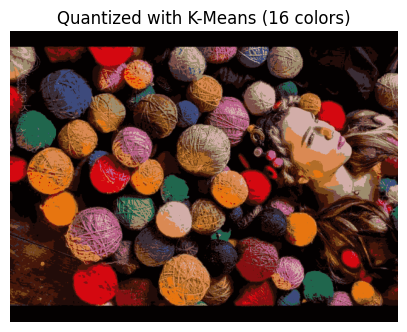

In [55]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title(f'Quantized with K-Means ({palette_size} colors)')
plt.imshow(recreate_image(kmeans_model.cluster_centers_, pixel_labels, img_width, img_height))
plt.show()

In [56]:
kmeans_model.cluster_centers_

array([[0.1338334 , 0.04948019, 0.03771549],
       [0.8563097 , 0.5387632 , 0.32709904],
       [0.48538661, 0.30884203, 0.28605253],
       [0.69934641, 0.42834967, 0.1629902 ],
       [0.52665214, 0.06230937, 0.07058824],
       [0.61736695, 0.55      , 0.42745098],
       [0.0163017 , 0.00586804, 0.0059396 ],
       [0.2283066 , 0.17860963, 0.21276292],
       [0.83507003, 0.03170868, 0.06330532],
       [0.24117647, 0.29150327, 0.48954248],
       [0.82418301, 0.68169935, 0.66154684],
       [0.45434174, 0.26386555, 0.09467787],
       [0.90745098, 0.46258824, 0.06431373],
       [0.27679325, 0.092827  , 0.04269049],
       [0.73812636, 0.38213508, 0.5449528 ],
       [0.12843137, 0.40065359, 0.30359477]])

Стискання за допомогою K-Means до 8 кольорів

In [57]:
palette_size = 8

In [58]:
sample_pixels = shuffle(pixels_2d, random_state=0, n_samples=1000)
sample_pixels

array([[0.08627451, 0.03137255, 0.        ],
       [0.01568627, 0.01568627, 0.02352941],
       [0.61960784, 0.21568627, 0.32941176],
       ...,
       [0.16470588, 0.09411765, 0.01568627],
       [0.82745098, 0.62352941, 0.54117647],
       [0.00392157, 0.        , 0.        ]], shape=(1000, 3))

In [59]:
kmeans_model = KMeans(n_clusters=palette_size, random_state=0)
kmeans_model.fit(sample_pixels)
pixel_labels = kmeans_model.predict(pixels_2d)
pixel_labels

array([6, 6, 6, ..., 6, 6, 6], shape=(307200,), dtype=int32)

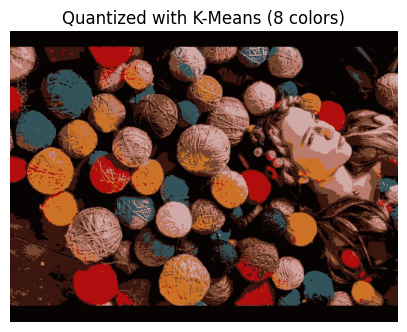

In [60]:
plt.figure(figsize=(5, 5))
plt.axis('off')
plt.title(f'Quantized with K-Means ({palette_size} colors)')
plt.imshow(recreate_image(kmeans_model.cluster_centers_, pixel_labels, img_width, img_height))
plt.show()

In [61]:
kmeans_model.cluster_centers_

array([[0.23218459, 0.08783918, 0.06171519],
       [0.73239216, 0.48407843, 0.43649673],
       [0.46485671, 0.27504609, 0.18401207],
       [0.79948027, 0.4508859 , 0.15161824],
       [0.68658824, 0.05155556, 0.05673203],
       [0.81874701, 0.66877092, 0.65375418],
       [0.03380936, 0.01225207, 0.01230874],
       [0.20337858, 0.32597285, 0.35704374]])

## **Завдання 3:**
Обробка та класифікація текстових даних

In [96]:
from nltk import download
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from string import punctuation
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

Завантажуємо стоп-слова

In [63]:
download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\grusevd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Проводимо передобробку тексту

In [97]:
def preprocess_text(text_line, stopword_list):
    if not isinstance(text_line, str):
        text_line = "" if pd.isna(text_line) else str(text_line)
    cleaned = text_line.lower()
    cleaned = re.sub(r'@\S+', ' ', cleaned)
    cleaned = re.sub(r'https*\S+', ' ', cleaned)
    cleaned = re.sub(r'#\S+', ' ', cleaned)
    cleaned = re.sub(r'\d', ' ', cleaned)
    cleaned = re.sub(r'[%s]' % re.escape(punctuation), ' ', cleaned)
    cleaned = re.sub(r'\n', ' ', cleaned)
    cleaned = re.sub(r'\s{2,}', ' ', cleaned)

    cleaned = ' '.join(
        token for token in cleaned.split(' ') if token and token not in stopword_list
    )
    return cleaned


Для завдання я обрав датасет відгуків про Instagram з Google Play Store за проміжок Вересень 2018 - Липень 2023 року. Датасет містить відгук, що складається з власне тексту та кількість зірок. Кількість зірок, для спрощення, я перетворив у бінарний класифікатор positive або negativ

Посилання: https://www.kaggle.com/datasets/saloni1712/instagram-play-store-reviews

Проведемо загальний огляд датасету.

In [65]:
instagram_reviews = pd.read_csv('var_data/instagram.csv')
instagram_reviews

,Review,label
0,"The app is good for connecting with friends, f...",NEGATIVE
1,"Used to be my favorite social media app, but ""...",NEGATIVE
2,Instagram is the best of all the social media....,POSITIVE
3,"I love this app.. but as of late, I have been ...",NEGATIVE
4,Used to be a great app but there are so many m...,NEGATIVE
...,...,...
210537,I love the app but lately my dms have been mes...,NEGATIVE
210538,Fun and addictive. Let's me see new ideas for ...,POSITIVE
210539,User friendly and all things are available for...,POSITIVE
210540,There are issues when you upload a story from ...,NEGATIVE


In [66]:
instagram_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210542 entries, 0 to 210541
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Review  210542 non-null  object
 1   label   210542 non-null  object
dtypes: object(2)
memory usage: 3.2+ MB


In [67]:
instagram_reviews.shape

(210542, 2)

In [68]:
text_col = instagram_reviews.columns[0]
label_col = instagram_reviews.columns[1]
text_col, label_col

('Review', 'label')

In [69]:
instagram_reviews.columns

Index(['Review', 'label'], dtype='object')

In [70]:
instagram_reviews.head()

,Review,label
0,"The app is good for connecting with friends, f...",NEGATIVE
1,"Used to be my favorite social media app, but ""...",NEGATIVE
2,Instagram is the best of all the social media....,POSITIVE
3,"I love this app.. but as of late, I have been ...",NEGATIVE
4,Used to be a great app but there are so many m...,NEGATIVE


In [98]:
from collections import Counter
label_counts = Counter(instagram_reviews[label_col])
label_counts

Counter({'NEGATIVE': 147082, 'POSITIVE': 63460})

Очистимо тексти відгуків від пунктуації, чисел та загальних для мови неінформативних слів

In [99]:
english_stopwords = stopwords.words('english')
english_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [73]:
instagram_reviews[text_col] = instagram_reviews[text_col].map(
    lambda review: preprocess_text(review, english_stopwords)
)
instagram_reviews

,Review,label
0,app good connecting friends family even potent...,NEGATIVE
1,used favorite social media app improvements ma...,NEGATIVE
2,instagram best social media ig posting platfor...,POSITIVE
3,love app late problems screen background turni...,NEGATIVE
4,used great app many bugs issues ever plus ruin...,NEGATIVE
...,...,...
210537,love app lately dms messing badly take send re...,NEGATIVE
210538,fun addictive let see new ideas craft bunch co...,POSITIVE
210539,user friendly things available entertainment c...,POSITIVE
210540,issues upload story redmi k viewed friends app...,NEGATIVE


In [74]:
instagram_reviews.head()

,Review,label
0,app good connecting friends family even potent...,NEGATIVE
1,used favorite social media app improvements ma...,NEGATIVE
2,instagram best social media ig posting platfor...,POSITIVE
3,love app late problems screen background turni...,NEGATIVE
4,used great app many bugs issues ever plus ruin...,NEGATIVE


Візуалізація: зобразимо для обох класів Хмари Слів

In [75]:
from wordcloud import WordCloud
def create_wordcloud(df, class_label):
    all_text = ' '.join(
        review.lower()
        for review in df[df[label_col] == class_label][text_col]
    )
    if len(all_text.strip()) == 0:
        return

    wc = WordCloud(width=600, height=400, background_color="white").generate(all_text)
    plt.figure(figsize=(8, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for '{class_label}'")
    plt.show()

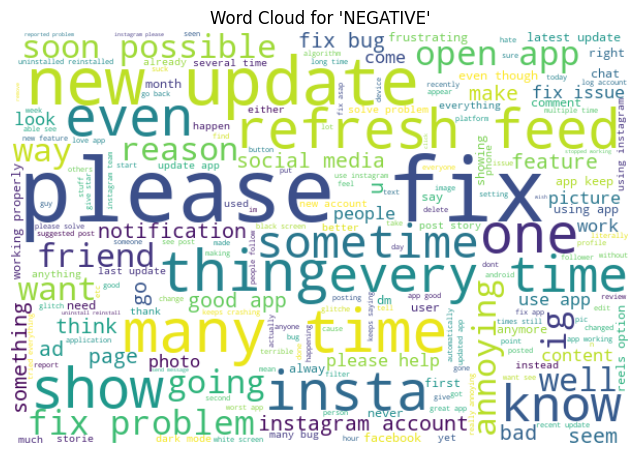

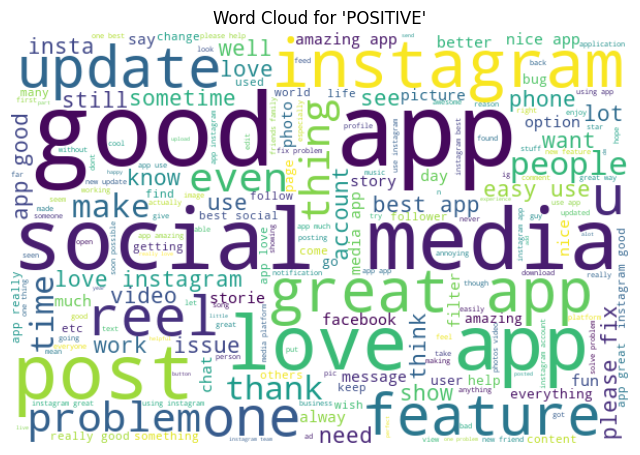

In [76]:
for class_name in instagram_reviews[label_col].unique():
    create_wordcloud(instagram_reviews, class_name)

Розіб'ємо датасет на тренувальні дані та дані для перевірки

Розділяємо дані на тренувальні та тестові

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    instagram_reviews[text_col].fillna("").astype(str),
    instagram_reviews[label_col],
    test_size=0.2,
    random_state=42,
    stratify=instagram_reviews[label_col] if instagram_reviews[label_col].nunique() > 1 else None
)
X_train

74336     music feature really annoying every time try p...
204468    using app form many time wonderful app one pro...
104761    nicest social network 😊 sometimes may stuck ad...
165024    recent update sucks story sharing worst task p...
50895     updates useless screw app together audio stori...
                                ...                        
78711     problem put location want put want put locatio...
117606    cannot able trim edit video posting really har...
186136    app must accessible visually impaired must abl...
191336           idea instagram work wifi fine assuming app
163397    every time try opening says cant refresh feed ...
Name: Review, Length: 168433, dtype: object

In [78]:
X_test

2503      know happened update whenever view story flick...
26731     reels options available ig account response he...
12281     facing bug issue app crashing closing frequent...
47875     best social networking tool keep times right f...
5514      get professionals think get away removing mute...
                                ...                        
43368     although good app many bugs like reels view op...
42844     good app social use issue video become viral v...
108668    downloaded app find longer access themes tab c...
13245     sometimes uploads video take song also sometim...
108555    got minor bug change phone mode normal battery...
Name: Review, Length: 42109, dtype: object

In [79]:
y_train

74336     NEGATIVE
204468    POSITIVE
104761    NEGATIVE
165024    NEGATIVE
50895     NEGATIVE
            ...   
78711     POSITIVE
117606    NEGATIVE
186136    NEGATIVE
191336    NEGATIVE
163397    NEGATIVE
Name: label, Length: 168433, dtype: object

In [80]:
y_test

2503      NEGATIVE
26731     NEGATIVE
12281     NEGATIVE
47875     POSITIVE
5514      POSITIVE
            ...   
43368     NEGATIVE
42844     POSITIVE
108668    NEGATIVE
13245     NEGATIVE
108555    POSITIVE
Name: label, Length: 42109, dtype: object

In [81]:
len(X_train), len(y_train), len(X_test), len(y_test)

(168433, 168433, 42109, 42109)

Векторизуємо дані за допомогою TfidfVectorizer

Таким чином перетворимо nекстові дані в оцінку та підготуємо дані для тренування моделі.

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_df=0.8)
tfidf_vectorizer

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


Навчаємо векторизатор на тренувальних даних та перетворюємо тексти в матрицю ознак

In [83]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2834886 stored elements and shape (168433, 43935)>

Перетворюємо тестові дані за вже навченим векторизатором

In [84]:
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_test_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 703144 stored elements and shape (42109, 43935)>

Перша модель: Native баєсівський класифікатор

In [85]:
from sklearn.naive_bayes import MultinomialNB

Підберемо параметр згладжування, що дасть найменшу помилку (заради цікавості, це в завданні не просили)

In [86]:
error_rate = {}
for a in [x / 10.0 for x in range(1, 20)]:
    nb_trial = MultinomialNB(alpha=a)
    nb_trial.fit(X_train_tfidf, y_train)
    pred_a = nb_trial.predict(X_test_tfidf)
    error_rate[a] = np.mean(pred_a != y_test)

error_rate

{0.1: np.float64(0.15417131729559003),
 0.2: np.float64(0.15353012420147713),
 0.3: np.float64(0.15424256097271366),
 0.4: np.float64(0.15433755254221188),
 0.5: np.float64(0.15469377092783015),
 0.6: np.float64(0.15545370348381582),
 0.7: np.float64(0.1561898881474269),
 0.8: np.float64(0.15766225747464913),
 0.9: np.float64(0.15887339998575126),
 1.0: np.float64(0.15968082832648603),
 1.1: np.float64(0.16070198769859176),
 1.2: np.float64(0.16224560070293761),
 1.3: np.float64(0.16376546581490892),
 1.4: np.float64(0.16497660832601108),
 1.5: np.float64(0.1661402550523641),
 1.6: np.float64(0.16739889334821534),
 1.7: np.float64(0.16858628796694294),
 1.8: np.float64(0.16984492626279418),
 1.9: np.float64(0.17119855612814364)}

In [87]:
alph = min(error_rate, key=error_rate.get)
alph, error_rate[alph]

(0.2, np.float64(0.15353012420147713))

Навчання та застосування моделі до тестового набору даних.

In [88]:
nb = MultinomialNB(alpha=alph)
nb.fit(X_train_tfidf, y_train)

,alpha,0.2
,force_alpha,True
,fit_prior,True
,class_prior,None


In [89]:
y_pred = nb.predict(X_test_tfidf)
y_pred

array(['NEGATIVE', 'NEGATIVE', 'NEGATIVE', ..., 'NEGATIVE', 'NEGATIVE',
       'NEGATIVE'], shape=(42109,), dtype='<U8')

In [91]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

    NEGATIVE       0.84      0.96      0.90     29417
    POSITIVE       0.86      0.59      0.70     12692

    accuracy                           0.85     42109
   macro avg       0.85      0.77      0.80     42109
weighted avg       0.85      0.85      0.84     42109

[[28190  1227]
 [ 5238  7454]]


Друга модель: Логістична Регресія

Ця модель застосовна, так як наші дані мають binary data type. Фактично NEGATIVE == 0 і POSITIV == 1. (або навпаки)

In [92]:
from sklearn.linear_model import LogisticRegression

In [93]:
classifier = LogisticRegression()
classifier.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [94]:
lr_predict = classifier.predict(X_test_tfidf)
lr_predict

array(['NEGATIVE', 'NEGATIVE', 'NEGATIVE', ..., 'NEGATIVE', 'NEGATIVE',
       'NEGATIVE'], shape=(42109,), dtype=object)

In [95]:
print(classification_report(y_test, lr_predict))
print(confusion_matrix(y_test, lr_predict))

              precision    recall  f1-score   support

    NEGATIVE       0.87      0.94      0.91     29417
    POSITIVE       0.84      0.68      0.75     12692

    accuracy                           0.86     42109
   macro avg       0.85      0.81      0.83     42109
weighted avg       0.86      0.86      0.86     42109

[[27719  1698]
 [ 4070  8622]]


### Висновки та оцінка якості обраних моделей:

Обидві моделі показали **високу якість класифікації** з accuracy 85-86%, що є **дуже добрим результатом** для задачі аналізу sentiment текстів.

#### Logistic Regression краща, бо:

- **Вища точність** (86% vs 85%)
- **Краще розпізнає POSITIVE відгуки** (+9% recall: 68% vs 59%)
- **Більш збалансована робота** між класами
- **На 22% менше False Negatives** (4,070 vs 5,238)
- **Вищий weighted F1-score** (0.86 vs 0.84)

**Коли використовувати Nativ Baysian:**
- Якщо **критично важливо виявити всі негативні відгуки** (recall 96%!)
- Коли потрібна **швидкість роботи** (NB простіший та швидший)
- Для попереднього фільтрування явно негативних кейсів

#### Незбалансованість має вплив

**Розподіл класів:**
- NEGATIVE: 147,082 відгуків (70%)
- POSITIVE: 63,460 відгуків (30%)

**Наслідки дисбалансу:**
- Обидві моделі **краще навчились розпізнавати NEGATIVE** клас (більше прикладів)
- POSITIVE клас розпізнається **гірше** через меншу кількість тренувальних даних
- Naive Bayes **більш чутливий до дисбалансу** (recall POS лише 59%)
- Logistic Regression **краще справляється з дисбалансом** завдяки регуляризації

### Аналіз помилок

**False Negatives (найбільш критичні помилки): (помилка 2 роду)**
- NB помилково класифікує як негативні **5,238 позитивних відгуків**
- LR помилково класифікує як негативні **4,070 позитивних відгуків**
- LR робить на **1,168 помилок менше** (покращення на 22%)

**False Positives (менш критичні): (помилка 1 роду)**
- NB помилково класифікує як позитивні **1,227 негативних відгуків**
- LR помилково класифікує як позитивні **1,698 негативних відгуків**

**Покращення:**
1. **Feature Engineering:**
   - Додати n-грами (біграми, триграми)
   - Додати ознаки довжини тексту, emojis

2. **Застосувати інші моделі:**
   - Random Forest
   - SVM з різними ядрами
   - Ensemble методи (voting, stacking)
   - Нейронні мережі (LSTM, BERT)
   - Для LR: регуляризація (C parameter)
   - Grid Search або Random Search
   - Додати deep learning

#### Оцінка якості моделей:

| Критерій | Naive Bayes | Logistic Regression | Переможець |
|----------|-------------|---------------------|------------|
| **Accuracy** | 85% | **86%** | LR |
| **Recall NEGATIVE** | **96%** | 94% | NB |
| **Recall POSITIVE** | 59% | **68%** | LR |
| **F1-score загальний** | 0.84 | **0.86** | LR |
| **Збалансованість** | Низька | **Висока** | LR |
| **Швидкість** | **Швидка** | Середня | NB |
| **Інтерпретованість** | **Висока** | Висока | Обидві |